In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("synthetic_water_usage.csv")
df.head()

,Population,Temperature,Rainfall,Industrial_Usage,Water_Usage
0,20795,28.726286,156.863846,14332.967858,83671.528600
1,5860,26.681682,303.185472,19002.496139,92808.162878
2,81820,39.350390,69.599012,1112.725519,37222.695146
3,59886,17.177715,449.130814,14855.908289,32486.907683
4,11265,43.879792,414.666203,6939.734197,75193.174592


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Population        1000 non-null   int64  
 1   Temperature       1000 non-null   float64
 2   Rainfall          1000 non-null   float64
 3   Industrial_Usage  1000 non-null   float64
 4   Water_Usage       1000 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 39.2 KB


In [5]:
df.describe()

,Population,Temperature,Rainfall,Industrial_Usage,Water_Usage
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,52442.588000,27.766302,248.323164,10666.681981,48426.311629
std,28165.681985,9.873881,146.498222,5514.412290,28809.610913
min,5055.000000,10.008313,0.094200,508.634238,1018.466289
25%,28058.000000,19.198742,116.310997,6171.876943,23395.258994
50%,53031.000000,28.298069,250.346012,10908.534024,46691.519834
75%,76915.500000,36.116994,375.671982,15377.468305,73445.101431
max,99856.000000,44.977372,499.856902,19991.106415,99764.659403


In [6]:
df.isnull().sum()

,0
Population,0
Temperature,0
Rainfall,0
Industrial_Usage,0
Water_Usage,0


[]

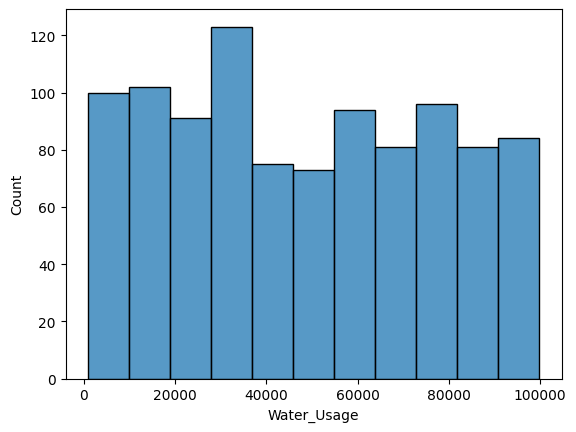

In [7]:
sns.histplot(df["Water_Usage"])
plt.plot()

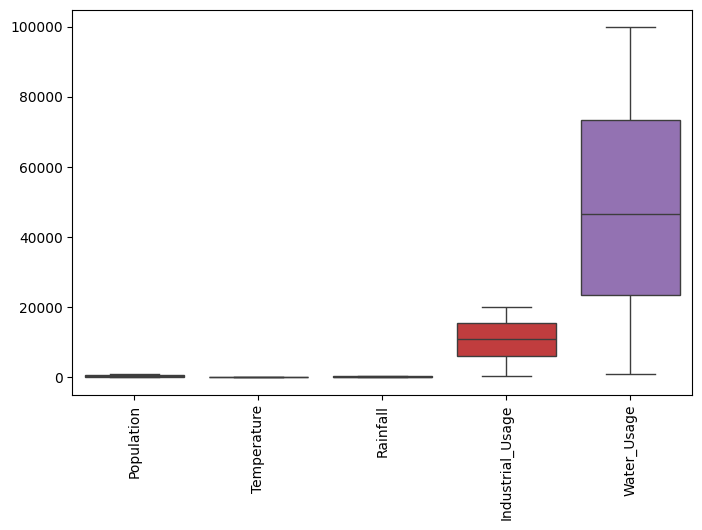

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Population'] = label_encoder.fit_transform(df['Population'])

In [15]:
from sklearn.model_selection import train_test_split
x = df.drop(columns=["Water_Usage"])
y = df["Water_Usage"]

In [16]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)


In [18]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(xtrain, ytrain)

LinearRegression()

In [19]:
ypred = model.predict(xtest)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(ytest, ypred)
mse = mean_squared_error(ytest, ypred)
r2 = r2_score(ytest, ypred)

# Print results
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared Score:", r2)

Mean Absolute Error: 25432.51724983848
Mean Squared Error: 849939318.0061667
R-squared Score: -0.07038806758768423


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>